In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import matplotlib.pyplot as plt
# Load the dataset
df = pd.read_csv('..//Data/patch.csv')

print(df.columns)


Index(['country', 'year', 'host', 'Aquatics', 'Aquatics_gold',
       'Aquatics_silver', 'Aquatics_bronze', 'Aquatics_no', 'Archery',
       'Archery_gold',
       ...
       'Weightlifting_bronze', 'Weightlifting_no', 'Wrestling',
       'Wrestling_gold', 'Wrestling_silver', 'Wrestling_bronze',
       'Wrestling_no', 'medal_gold', 'medal_silver', 'medal_bronze'],
      dtype='object', length=236)


In [2]:
# Add penalty feature for countries with no gold in the last Olympics
# df['no_gold_last_time'] = df.groupby('country')['medal_gold'].shift(1).fillna(0).apply(lambda x: 1 if x == 0 else 0)

# Add gold medal count from last Olympics
df['gold_last_count'] = df.groupby('country')['medal_gold'].shift(1).fillna(0)

# Split the data into training and testing sets
train_inputs = df[df['year'] < 2027].iloc[:, :233]
train_target = df[df['year'] < 2027].iloc[:, 233:]
test_inputs = df[df['year'] >= 2027].iloc[:, :233]
test_target = df[df['year'] >= 2027].iloc[:, 233:]

train_country_year = train_inputs.iloc[:, [0, 1]]
test_country_year = test_inputs.iloc[:, [0, 1]]

# Add the penalty feature and gold_last_count to the training and testing inputs
# train_inputs['no_gold_last_time'] = df[df['year'] < 2027]['no_gold_last_time']
# test_inputs['no_gold_last_time'] = df[df['year'] >= 2027]['no_gold_last_time']
train_inputs['gold_last_count'] = df[df['year'] < 2027]['gold_last_count']
test_inputs['gold_last_count'] = df[df['year'] >= 2027]['gold_last_count']


# train_target = train_target.drop(['no_gold_last_time','gold_last_count'], axis=1)
# test_target = test_target.drop(['no_gold_last_time','gold_last_count'], axis=1)

# Drop non-numeric or unnecessary columns
train_inputs = train_inputs.drop(['country'], axis=1)
test_inputs = test_inputs.drop(['country'], axis=1)

print(train_inputs.columns)
print(test_inputs.columns)
print(train_target.columns)
print(test_target.columns)

# Separate time (year) and features
train_time_col = train_inputs['year']
train_features = train_inputs.drop(columns=['year'])

test_time_col = test_inputs['year']
test_features = test_inputs.drop(columns=['year'])

# Normalize the features
scaler = MinMaxScaler()
train_features_normalized = scaler.fit_transform(train_features)
test_features_normalized = scaler.transform(test_features)

# Convert data to PyTorch tensors
train_features_tensor = torch.tensor(train_features_normalized, dtype=torch.float32)
train_target_tensor = torch.tensor(train_target.values, dtype=torch.float32)
test_features_tensor = torch.tensor(test_features_normalized, dtype=torch.float32)
test_target_tensor = torch.tensor(test_target.values, dtype=torch.float32)

Index(['year', 'host', 'Aquatics', 'Aquatics_gold', 'Aquatics_silver',
       'Aquatics_bronze', 'Aquatics_no', 'Archery', 'Archery_gold',
       'Archery_silver',
       ...
       'Weightlifting_silver', 'Weightlifting_bronze', 'Weightlifting_no',
       'Wrestling', 'Wrestling_gold', 'Wrestling_silver', 'Wrestling_bronze',
       'Wrestling_no', 'no_gold_last_time', 'gold_last_count'],
      dtype='object', length=234)
Index(['year', 'host', 'Aquatics', 'Aquatics_gold', 'Aquatics_silver',
       'Aquatics_bronze', 'Aquatics_no', 'Archery', 'Archery_gold',
       'Archery_silver',
       ...
       'Weightlifting_silver', 'Weightlifting_bronze', 'Weightlifting_no',
       'Wrestling', 'Wrestling_gold', 'Wrestling_silver', 'Wrestling_bronze',
       'Wrestling_no', 'no_gold_last_time', 'gold_last_count'],
      dtype='object', length=234)
Index(['medal_gold', 'medal_silver', 'medal_bronze'], dtype='object')
Index(['medal_gold', 'medal_silver', 'medal_bronze'], dtype='object')


In [3]:
# LSTM model definition
class OlympicLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers):
        super(OlympicLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :])
        return out

# Custom loss function with penalty for countries with no gold in the last Olympics
class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()
        self.mse = nn.MSELoss()

#     def forward(self, outputs, targets, no_gold_last_time):
        loss = self.mse(outputs, targets)
        # Apply penalty for countries with no gold in the last Olympics
#         penalty = torch.sum(no_gold_last_time * outputs[:, 0])  # Assuming gold medal prediction is the first column
        return loss + 0.1 * penalty  # Penalty coefficient (adjustable)


In [4]:
# Model parameters
input_dim = train_features_tensor.shape[1]
hidden_dim = 128
output_dim = train_target_tensor.shape[1]
num_layers = 2
learning_rate = 0.005
epochs = 300
batch_size = 32

# Create datasets and dataloaders
train_dataset = torch.utils.data.TensorDataset(train_features_tensor, train_target_tensor, 
#                                                torch.tensor(df[df['year'] < 2027]['no_gold_last_time'].values, dtype=torch.float32))
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torch.utils.data.TensorDataset(test_features_tensor, test_target_tensor, 
#                                               torch.tensor(df[df['year'] >= 2027]['no_gold_last_time'].values, dtype=torch.float32))
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

# Initialize the model, loss function, and optimizer
model = OlympicLSTM(input_dim, hidden_dim, output_dim, num_layers)
criterion = CustomLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [5]:
# Training loop
train_losses = []
model.train()
for epoch in range(epochs):
    epoch_loss = 0.0
#     for inputs, targets, no_gold_last_time in train_loader:
    inputs = inputs.unsqueeze(1)  # Add sequence dimension

    optimizer.zero_grad()
    outputs = model(inputs)
#         loss = criterion(outputs, targets, no_gold_last_time)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()

    epoch_loss /= len(train_loader)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}')


Epoch [1/300], Loss: 4.3823
Epoch [2/300], Loss: 0.8046
Epoch [3/300], Loss: 0.1634
Epoch [4/300], Loss: -0.0659
Epoch [5/300], Loss: -0.2436
Epoch [6/300], Loss: -0.7933
Epoch [7/300], Loss: -0.9199
Epoch [8/300], Loss: -1.2511
Epoch [9/300], Loss: -1.6047
Epoch [10/300], Loss: -1.8162
Epoch [11/300], Loss: -2.1180
Epoch [12/300], Loss: -2.4207
Epoch [13/300], Loss: -2.6971
Epoch [14/300], Loss: -2.9106
Epoch [15/300], Loss: -3.0556
Epoch [16/300], Loss: -3.2210
Epoch [17/300], Loss: -3.2964
Epoch [18/300], Loss: -3.3914
Epoch [19/300], Loss: -3.4614
Epoch [20/300], Loss: -3.4535
Epoch [21/300], Loss: -3.4942
Epoch [22/300], Loss: -3.3940
Epoch [23/300], Loss: -3.5239
Epoch [24/300], Loss: -3.5292
Epoch [25/300], Loss: -3.5956
Epoch [26/300], Loss: -3.6282
Epoch [27/300], Loss: -3.4206
Epoch [28/300], Loss: -3.6773
Epoch [29/300], Loss: -3.7369
Epoch [30/300], Loss: -3.7737
Epoch [31/300], Loss: -3.8082
Epoch [32/300], Loss: -3.8428
Epoch [33/300], Loss: -3.8410
Epoch [34/300], Loss: 

KeyboardInterrupt: 

In [12]:
# Evaluation
model.eval()
with torch.no_grad():
    test_predictions = []
    test_targets = []

#     for inputs, targets, no_gold_last_time in test_loader:
        inputs = inputs.unsqueeze(1)
        outputs = model(inputs)

        # Apply rounding and set negatives to zero
        rounded_outputs = torch.round(outputs)
        rounded_outputs = torch.clamp(rounded_outputs, min=0)  # Clamp all values to be >= 0

        test_predictions.append(rounded_outputs.numpy())
        test_targets.append(targets.numpy())

    test_predictions = np.vstack(test_predictions)
    test_targets = np.vstack(test_targets)

    mae = mean_absolute_error(test_targets, test_predictions)
    rmse = np.sqrt(mean_squared_error(test_targets, test_predictions))

    print(f'Test MAE: {mae:.4f}')
    print(f'Test RMSE: {rmse:.4f}')

predicted_df = pd.DataFrame(test_predictions)
test_country_year.reset_index(drop=True, inplace=True)
predicted_df.reset_index(drop=True, inplace=True)

output = pd.concat([test_country_year, predicted_df], axis=1)
print(output)
output.to_csv('..//output//output.csv', index=False)


Test MAE: 6.6047
Test RMSE: 9.4416
               country  year     0     1     2
0          Afghanistan  2028   0.0   3.0   3.0
1              Albania  2028   0.0   3.0   3.0
2              Algeria  2028   5.0   3.0   3.0
3              Andorra  2028   6.0   4.0   8.0
4               Angola  2028   2.0   2.0   2.0
..                 ...   ...   ...   ...   ...
210         Yugoslavia  2028  18.0  20.0  20.0
211  Yugoslaviaoslavia  2028  18.0  20.0  20.0
212             Zambia  2028   0.0   1.0   2.0
213           Zimbabwe  2028   0.0   2.0   2.0
214        the Solomon  2028   7.0   5.0   9.0

[215 rows x 5 columns]


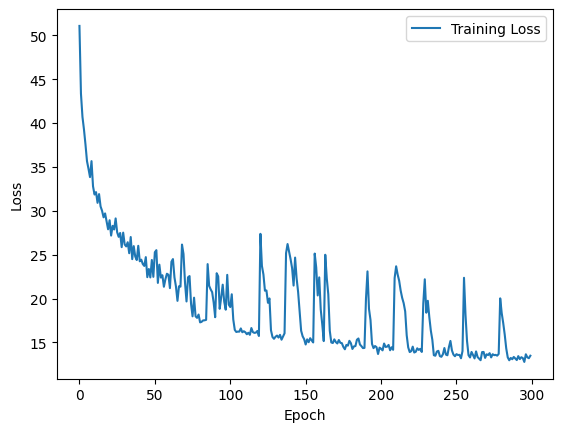

In [13]:
# Plot training loss
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
